# testSCVIbatch.ipynb — cross-batch pair-MSE alignment loss

Inherits from `testRUVVAE_ZINB.ipynb` (uses the same TH subset + scVI-style
data prep). Calls [`model_scvi_batch_pair.SCVIWithBatchPairLoss`](model_scvi_batch_pair.py)
which adds an extra cross-batch MSE term to the standard scVI loss.

Pipeline:
1. Load data & prepare scVI format (counts in X, n_genes_on covariate)
2. `setup_anndata` + build `SCVIWithBatchPairLoss`
3. Forward validation: `pair_loss > 0` only when mini-batch has ≥ 2 batches
4. Train (100 epochs), watch `batch_pair_mse`
5. Evaluate alignment: iLISI / ASW vs baseline SCVI
6. Visualise: UMAP by batch, per-pair MSE convergence, latent `z` distribution

In [1]:
# ========== Load the same data subset as testRUVVAE_ZINB.ipynb ==========
import scanpy as sc

adata = sc.read_h5ad(
    "/data3/junyi/six_datasets_4v3_500_1000gene_batchscvi/TH_batchscvi_full.h5ad"
)

# adata_subset = adata[
#     adata.obs["celltype.L2"].isin(
#         adata.obs["celltype.L2"].value_counts().head(2).index[1:2]
#     )
# ]
# adata_subset = adata_subset[adata_subset.obs["sex"] == "M"]

print(f"adata_subset shape: {adata.shape}")
print(f"status counts:\n{adata.obs['status'].value_counts()}")
print(f"company counts:\n{adata.obs['company'].value_counts()}")

adata_subset shape: (201921, 16428)
status counts:
status
CUSUS    55281
CON      53738
CURES    44435
CSRES    25445
CSSUS    23022
Name: count, dtype: int64
company counts:
company
beirui      144702
seekgene     36520
yunzhun      20699
Name: count, dtype: int64


In [14]:
sc.pp.normalize_total(adata, target_sum=1e4)

/home/junyichen/anaconda3/envs/scvi-env/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


In [17]:
# print the max,min,mean value of the normalized in batchpair_D1_normlized 
# print the max, min, mean value of the normalized data in adata.X
print(f"Max value in adata.X: {adata.X.max()}")
print(f"Min value in adata.X: {adata.X.min()}")
print(f"Mean value in adata.X: {adata.X.mean()}")


Max value in adata.X: 6111.92919921875
Min value in adata.X: 0.0
Mean value in adata.X: 0.6087167859077454


In [18]:
# print the max, min, mean value of the normalized data in adata.X
print(f"Max value in adata.X: {adata.layers['batchpair_D1_normlized'].max()}")
print(f"Min value in adata.X: {adata.layers['batchpair_D1_normlized'].min()}")
print(f"Mean value in adata.X: {adata.layers['batchpair_D1_normlized'].mean()}")


Max value in adata.X: 3779.175048828125
Min value in adata.X: 0.0001539002259960398
Mean value in adata.X: 0.6087169647216797


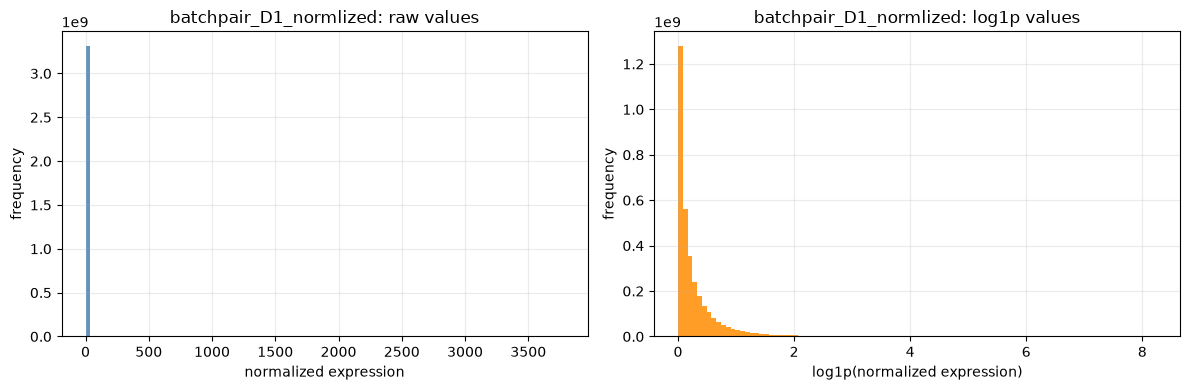

n values: 3317158188
min: 0.0001539
max: 3779.18
mean: 0.608717


In [24]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.sparse import issparse

layer_name = "batchpair_D1_normlized"
layer = adata.layers[layer_name]
values = (
    layer.toarray().ravel()
    if issparse(layer)
    else np.asarray(layer).ravel()
)
values = values[np.isfinite(values)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(values, bins=100, color="steelblue", alpha=0.85)
axes[0].set_title(f"{layer_name}: raw values")
axes[0].set_xlabel("normalized expression")
axes[0].set_ylabel("frequency")
axes[0].grid(alpha=0.25)

axes[1].hist(np.log1p(values), bins=100, color="darkorange", alpha=0.85)
axes[1].set_title(f"{layer_name}: log1p values")
axes[1].set_xlabel("log1p(normalized expression)")
axes[1].set_ylabel("frequency")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f"n values: {values.size}")
print(f"min: {values.min():.6g}")
print(f"max: {values.max():.6g}")
print(f"mean: {values.mean():.6g}")

In [16]:
adata.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 501807424 stored elements and shape (201921, 16428)>

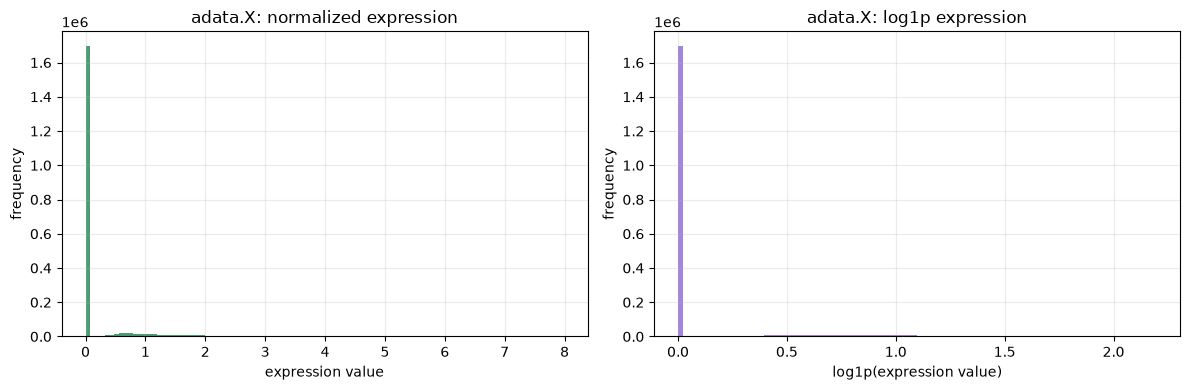

values plotted: 2000000
min: 0
max: 7.98327
mean: 0.18551


In [26]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.sparse import issparse

x = adata.X
values = x.toarray().ravel() if issparse(x) else np.asarray(x).ravel()
values = values[np.isfinite(values)]

# Limit plotting memory for very large matrices while keeping a reproducible sample.
rng = np.random.default_rng(42)
max_values = 2_000_000
if values.size > max_values:
    values = rng.choice(values, size=max_values, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(values, bins=100, color="seagreen", alpha=0.85)
axes[0].set_title("adata.X: normalized expression")
axes[0].set_xlabel("expression value")
axes[0].set_ylabel("frequency")
axes[0].grid(alpha=0.25)

axes[1].hist(np.log1p(values), bins=100, color="mediumpurple", alpha=0.85)
axes[1].set_title("adata.X: log1p expression")
axes[1].set_xlabel("log1p(expression value)")
axes[1].set_ylabel("frequency")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f"values plotted: {values.size}")
print(f"min: {values.min():.6g}")
print(f"max: {values.max():.6g}")
print(f"mean: {values.mean():.6g}")

In [ ]:
sc.tl.rank_genes_groups(adata, groupby="company", method="wilcoxon", n_genes=adata.shape[1])

Layers with keys: 'batchpair_D1_counts', 'batchpair_D1_normlized', 'count_diff', 'counts', 'scvi_reconstructed_counts', None

In [2]:
# ========== Prepare scVI-format data: raw counts in X + n_genes_on covariate ==========
import sys
sys.path.insert(0, "/home/junyichen/code/RUVAEDEG")
import numpy as np
import pandas as pd
import torch
from scipy.sparse import csr_matrix

adata_scvi = adata_subset.copy()

# counts → X
if "counts" in adata_scvi.layers:
    adata_scvi.X = adata_scvi.layers["counts"].copy()

X = adata_scvi.X.toarray() if hasattr(adata_scvi.X, "toarray") else adata_scvi.X.copy()
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
adata_scvi.X = csr_matrix(X.astype(np.float32))

# n_genes_on covariate (z-scored)
n_genes_on_raw = (adata_scvi.X > 0).sum(axis=1).astype(np.float32)
mu_, sd_ = float(n_genes_on_raw.mean()), float(n_genes_on_raw.std())
adata_scvi.obs["n_genes_on"] = (
    (n_genes_on_raw - mu_) / (sd_ + 1e-8)
).astype(np.float32)

print(f"adata_scvi shape: {adata_scvi.shape}")
print(f"X dtype/range: {adata_scvi.X.dtype} / [{adata_scvi.X.min()}, {adata_scvi.X.max()}]")
print(f"n_batches: {adata_scvi.obs['company'].nunique()}")
print(f"n_status: {adata_scvi.obs['status'].nunique()}")

adata_scvi shape: (13885, 16428)
X dtype/range: float32 / [0.0, 1900.0]
n_batches: 3
n_status: 5


In [3]:
# ========== Force correct dtypes before scVI registration ==========
# ``company`` (batch_key) must be ``category``; ``n_genes_on`` (continuous)
# must be ``float32``. Mixed dtypes are the typical cause of the
# ``RuntimeError: expand(... size=[1, 1, 255])`` raised by one_hot on a
# 4-D integer tensor coming out of the cat-covs registry.
adata_scvi.obs["company"] = adata_scvi.obs["company"].astype("category")
adata_scvi.obs["n_genes_on"] = adata_scvi.obs["n_genes_on"].astype(np.float32)
print("company dtype   :", adata_scvi.obs["company"].dtype)
print("n_genes_on dtype:", adata_scvi.obs["n_genes_on"].dtype)

company dtype   : category
n_genes_on dtype: float32


In [4]:
# ========== Import the new model and run setup_anndata + instantiation ==========
from model_scvi_batch_pair import SCVIWithBatchPairLoss, VAEWithBatchPairLoss

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

SCVIWithBatchPairLoss.setup_anndata(
    adata_scvi,
    pair_batch_obs_key="company",  # copied to `_pair_batch` and registered as cat cov
    batch_key=None,                # SCVI does NOT apply batch-correction at all
    labels_key=None,
    continuous_covariate_keys=[],  # pair-batch run uses no continuous covariates
)

PAIR_WEIGHT = 1.0
ALIGN_ON    = "mu"                            # "mu" (decoder rate) or "z" (latent)

model = SCVIWithBatchPairLoss(
    adata_scvi,
    n_latent=32,
    n_layers=2,
    gene_likelihood="zinb",
    pair_weight=PAIR_WEIGHT,
    align_on=ALIGN_ON,
    deeply_inject_covariates=False,  # decoder NEVER sees the pair batch — loss only
)

print(f"Module class:  {type(model.module).__name__}")
print(f"pair_weight:   {model.module.pair_weight}")
print(f"align_on:      {model.module.align_on}")
print(f"n_input genes: {model.module.n_input}")
print(f"n_batch:       {model.module.n_batch}")

/home/junyichen/anaconda3/envs/scvi-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Module class:  VAEWithBatchPairLoss
pair_weight:   1.0
align_on:      mu
n_input genes: 16428
n_batch:       1


## Forward validation: pair loss is positive only when a mini-batch spans ≥ 2 batches

In [5]:
# ========== StratifiedBatchSampler: guarantee every mini-batch spans all batches ==========
from torch.utils.data import Sampler

class StratifiedBatchSampler(Sampler):
    """Within each mini-batch draw (roughly) the same number of cells from
    every ``batch_key`` category. Guarantees every mini-batch spans >=2
    batches, so the cross-batch pair-MSE term is never degenerate.
    """

    def __init__(self, batch_codes: np.ndarray, batch_size: int, seed: int = 0):
        self.batch_codes = np.asarray(batch_codes)
        self.batch_size = int(batch_size)
        self.seed = int(seed)
        self.epoch = 0

        self.indices_per_batch = {
            b: np.where(self.batch_codes == b)[0]
            for b in np.unique(self.batch_codes)
        }
        self.batch_categories = list(self.indices_per_batch.keys())
        self.n_batches = len(self.batch_categories)
        self.per_batch_quota = max(1, self.batch_size // self.n_batches)
        self.effective_batch_size = self.per_batch_quota * self.n_batches

        # Number of mini-batches per epoch = the longest batch pool divided by quota.
        max_len = max(len(v) for v in self.indices_per_batch.values())
        self.num_iter = max_len // self.per_batch_quota

    def __iter__(self):
        rng = np.random.default_rng(self.seed + self.epoch)
        pools = {b: rng.permutation(idx).tolist()
                 for b, idx in self.indices_per_batch.items()}
        for it in range(self.num_iter):
            chunk = []
            for ids in pools.values():
                chunk.extend(ids[it * self.per_batch_quota:(it + 1) * self.per_batch_quota])
            rng.shuffle(chunk)
            yield chunk

    def __len__(self):
        return self.num_iter


# Build a sampler on the company batches, with effective batch_size = 256.
batch_codes = adata_scvi.obs["company"].cat.codes.to_numpy()
stratified_sampler = StratifiedBatchSampler(batch_codes, batch_size=256, seed=seed)
print(f"stratified sampler: {stratified_sampler.n_batches} batches × "
      f"{stratified_sampler.per_batch_quota} cells/batch = "
      f"effective batch size {stratified_sampler.effective_batch_size}, "
      f"{stratified_sampler.num_iter} mini-batches per epoch")

stratified sampler: 3 batches × 85 cells/batch = effective batch size 255, 124 mini-batches per epoch


In [ ]:
# ========== Forward sanity check (uses stratified sampler → always cross-batch) ==========
# Use the scVI model's own dataloader factory, which honours a custom
# `sampler` argument and avoids adata.create_torch_dataset (removed in
# newer scvi-tools releases).
train_loader = model._make_data_loader(
    adata=adata_scvi,
    indices=np.arange(adata_scvi.n_obs),
    batch_size=stratified_sampler.effective_batch_size,
    sampler=stratified_sampler,
    shuffle=False,
)

# ---- (a) Inspect one batch BEFORE calling forward ----
for tensors in train_loader:
    print("=" * 60)
    print("registry keys in this mini-batch:")
    for k, v in tensors.items():
        if hasattr(v, "shape"):
            print(f"  {k:30s} shape={tuple(v.shape)} dtype={v.dtype}")
        else:
            print(f"  {k:30s} value={v}")
    print("=" * 60)
    break
# ---- (b) Then call forward ----
for tensors in train_loader:
    inf, gen, loss = model.module.forward(tensors, compute_loss=True)
    print(f"px.mu shape:        {tuple(gen['px'].mu.shape)}")
    print(f"inference z shape:  {tuple(inf['z'].shape)}")
    print(f"loss (with pair):   {float(loss.loss):.4f}")
    print(f"  extra_metrics:    {loss.extra_metrics}")

    assert "batch_pair_mse" in loss.extra_metrics
    assert "batch_pair_n" in loss.extra_metrics
    assert loss.extra_metrics["batch_pair_n"] > 0, (
        f"stratified sampler should always give cross-batch pairs, got n={loss.extra_metrics['batch_pair_n']}"
    )
    print("✓ pair_mse > 0  ✓ n_pairs > 0 (cross-batch pairs present)")
    break

registry keys in this mini-batch:
  X                              shape=(1, 255, 16428) dtype=torch.float32
  batch                          shape=(1, 255, 1) dtype=torch.int64
  extra_categorical_covs         shape=(1, 255, 1) dtype=torch.int64
  labels                         shape=(1, 255, 1) dtype=torch.int64


RuntimeError: expand(torch.LongTensor{[1, 1, 1, 3]}, size=[1, 1, 1]): the number of sizes provided (3) must be greater or equal to the number of dimensions in the tensor (4)

: 

In [ ]:
# ========== Force a "single-batch" mini-batch to confirm pair_mse == 0 ==========
single_idx = adata_scvi.obs.index[adata_scvi.obs["company"] == adata_scvi.obs["company"].iloc[0]]
sub = adata_scvi[single_idx].copy()
scdl_single = model._make_data_loader(adata=sub, batch_size=64, shuffle=False)
for tensors in scdl_single:
    inf, gen, loss = model.module.forward(tensors, compute_loss=True)
    print(f"single-batch mini: pair_mse={loss.extra_metrics['batch_pair_mse']}, "
          f"n_pairs={loss.extra_metrics['batch_pair_n']}")
    assert loss.extra_metrics["batch_pair_n"] == 0
    assert loss.extra_metrics["batch_pair_mse"] == 0.0
    print("✓ single-batch mini returns 0 (degenerate case handled)")
    break

## Training: watch `batch_pair_mse` drop while scVI loss stays normal

In [ ]:
# ========== Train ==========
model.train(
    max_epochs=100,
    train_size=0.9,
    batch_size=256,
    early_stopping=True,
    early_stopping_patience=5,
    plan_kwargs={"lr": 1e-3},
)
print("✓ training complete")

In [ ]:
# ========== Training curves: total loss + pair_mse ==========
history = model.history_
elbo  = history["elbo_train"].astype(float)
recon = history["reconstruction_loss_train"].astype(float)
kl    = history["kl_local_train"].astype(float)

# scVI logs LossOutput.extra_metrics with names such as
# ``batch_pair_mse_train`` and ``batch_pair_n_train``.
metric_keys = [k for k in history.keys() if "batch_pair" in k]
print(f"Logged pair metrics: {metric_keys}")

pair_mse_per_epoch = None
for k in metric_keys:
    if "batch_pair_mse" in k:
        pair_mse_per_epoch = np.asarray(history[k], dtype=float)

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(elbo,  label="ELBO (train)")
axes[0].plot(recon, label="reconstruction_loss_train")
axes[0].plot(kl,    label="kl_local_train")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].legend()
axes[0].set_title("Training losses")
axes[0].grid(alpha=0.3)

if pair_mse_per_epoch is not None:
    axes[1].plot(pair_mse_per_epoch, label="batch_pair_mse", color="tab:red")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("pair MSE")
    axes[1].set_title("Cross-batch pair MSE (should drop)")
    axes[1].grid(alpha=0.3)
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, "batch_pair_mse not logged", ha="center")

plt.tight_layout()
fig.savefig(SLIDE_FIG_DIR / "training_losses_pair_mse.png", dpi=300, bbox_inches="tight")
fig.savefig(SLIDE_FIG_DIR / "training_losses_pair_mse.pdf", bbox_inches="tight")
plt.close(fig)

## Latent space & alignment evaluation

In [ ]:
# ========== Latent embedding + UMAP by batch ==========
adata_scvi.obsm["X_scVI_pair"] = model.get_latent_representation()

sc.pp.neighbors(adata_scvi, use_rep="X_scVI_pair")
sc.tl.umap(adata_scvi)
sc.pl.umap(
    adata_scvi,
    color=["company", "status"],
    ncols=2,
    title=["UMAP by company (batch)", "UMAP by status (bio)"],
    show=True,
)

In [ ]:
# ========== iLISI + silhouette: how well are batches mixed? ==========
import scanpy.external as sce
try:
    sce.pp.lisi_knn(
        adata_scvi,
        key=["company", "status"],
        use_rep="X_scVI_pair",
    )
    ilisi_batch = float(adata_scvi.obsm["X_lisi_company"].mean())
    ilisi_status = float(adata_scvi.obsm["X_lisi_status"].mean())
    n_batch = adata_scvi.obs["company"].nunique()
    print(f"iLISI (company):  {ilisi_batch:.3f}   (max = {n_batch}, larger = better mixed)")
    print(f"iLISI (status):   {ilisi_status:.3f}   (small = biology preserved)")
except Exception as exc:
    print(f"[warn] scanpy.external unavailable: {exc}")

from sklearn.metrics import silhouette_score
asw_batch = silhouette_score(adata_scvi.obsm["X_scVI_pair"], adata_scvi.obs["company"])
asw_bio   = silhouette_score(adata_scvi.obsm["X_scVI_pair"], adata_scvi.obs["status"])
print(f"ASW (company, ↓): {asw_batch:.4f}")
print(f"ASW (status,  ↑): {asw_bio:.4f}")

In [ ]:
# ========== Compare to plain SCVI (no pair loss) ==========
from scvi.model import SCVI as _SCVI

_SCVI.setup_anndata(
    adata_scvi,
    batch_key="company",
    labels_key=None,
    continuous_covariate_keys=["n_genes_on"],
)
m_plain = _SCVI(adata_scvi, n_latent=32, n_layers=2, gene_likelihood="zinb")
m_plain.train(max_epochs=100, train_size=0.9, batch_size=256,
              early_stopping=True, early_stopping_patience=5,
              plan_kwargs={"lr": 1e-3})
adata_scvi.obsm["X_scVI_plain"] = m_plain.get_latent_representation()

asw_batch_plain = silhouette_score(
    adata_scvi.obsm["X_scVI_plain"], adata_scvi.obs["company"]
)
asw_bio_plain = silhouette_score(
    adata_scvi.obsm["X_scVI_plain"], adata_scvi.obs["status"]
)

summary = pd.DataFrame(
    {
        "model": ["SCVI (baseline)", "SCVI + pair-MSE"],
        "ASW_company(↓)": [asw_batch_plain, asw_batch],
        "ASW_status(↑)":  [asw_bio_plain,   asw_bio],
    }
)
print("\n=== Batch alignment summary ===")
print(summary.to_string(index=False))

## Direct check: decoder `mu` is more uniform across batches after training

In [ ]:
# ========== Compare baseline SCVI vs pair model: per-pair cross-batch MSE on mu ==========
import torch
from model_scvi_batch_pair import _cross_batch_pair_mse

def _per_cell_mu(model_obj):
    out = []
    scdl = model_obj._make_data_loader(adata=adata_scvi, batch_size=512)
    for tensors in scdl:
        inf, gen = model_obj.module.forward(tensors, compute_loss=False)
        out.append(gen["px"].mu.detach().cpu())
    return torch.cat(out, 0)

mu_plain = _per_cell_mu(m_plain)
mu_pair  = _per_cell_mu(model)

batch_idx = torch.as_tensor(
    adata_scvi.obs["company"].cat.codes.to_numpy(), dtype=torch.long
)
loss_plain, n = _cross_batch_pair_mse(mu_plain, batch_idx)
loss_pair,  _ = _cross_batch_pair_mse(mu_pair,  batch_idx)

print(f"cross-batch mu-MSE on baseline SCVI: {float(loss_plain):.4f}")
print(f"cross-batch mu-MSE on pair-trained : {float(loss_pair):.4f}")
print(f"reduction: {(1 - float(loss_pair) / float(loss_plain)) * 100:.1f}%")

In [ ]:
# ========== Final summary ==========
print("=== testSCVIbatch summary ===")
print(f"Pair weight: {PAIR_WEIGHT}, align_on: {ALIGN_ON}")
print(f"iLISI(company)={ilisi_batch:.3f}/{n_batch}  ASW_company={asw_batch:.4f}  ASW_status={asw_bio:.4f}")
print(f"mu-MSE baseline={float(loss_plain):.4f}  pair={float(loss_pair):.4f}")
print("✓ Inherited SCVI training pipeline + cross-batch pair-MSE term")